# 12 Feature Family Value Results

This notebook is the dedicated reporting layer for the grouped feature-family ablation artifacts introduced in Phase 3.

It does not launch a new benchmark universe. Instead, it reads the latest complete saved aggregate ablation artifacts, explains what grouped ablation means, and highlights the feature families that currently look most valuable, weak, or context-dependent.

Primary reporting lens used for the cross-context synthesis:
- split: validation
- reporting level: full-horizon
- metric: MAE

That lens keeps the cross-context summary compact. Other reporting levels stay available as supporting context.


In [1]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys
import time

import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_CWD = Path.cwd()
REPO_ROOT = next(
    path for path in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents] if (path / "scripts/Data/02_Forecasting/01_DA_prices").exists()
)
os.chdir(REPO_ROOT)
PACKAGE_ROOT = REPO_ROOT / "scripts/Data/02_Forecasting/01_DA_prices"
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.append(str(PACKAGE_ROOT))

from hourly_da.core.config import HourlyDAPipelineConfig
from hourly_da.core.external_features import build_external_family_catalog, load_external_feature_store
from hourly_da.core.methodology import (
    STARTER_ENDOGENOUS_FEATURE_NOTE,
    feature_stage_policy_frame,
    model_status_frame,
    shortlisting_policy_frame,
)
from hourly_da.core.reporting import find_latest_run, load_csv, load_json
from hourly_da.core.tuning import build_tuning_placeholder, tuning_cadence_frame, tuning_snippet_frame
from hourly_da.models import naive_model_names
from hourly_da.notebook_support import estimate_run_duration_seconds, format_duration, load_selected_case_weeks

config = HourlyDAPipelineConfig(
    input_csv=REPO_ROOT / "data/01_cleaned/Day_ahead_prices/DA_prices/hourly/da_prices_all_regions_hourly.csv",
    raw_root=REPO_ROOT / "data/00_Raw/DA_Prices",
    cleaned_feature_root=REPO_ROOT / "data/01_cleaned",
    output_root=REPO_ROOT / "data/02_Forecasting/01_DA_prices/hourly_da",
)
output_root = config.output_root


def latest_run_or_none(run_label: str) -> Path | None:
    try:
        return find_latest_run(output_root, run_label)
    except FileNotFoundError:
        return None


def ensure_required_modules(module_names: list[str], install_command: str | None = None) -> None:
    missing = [module_name for module_name in module_names if importlib.util.find_spec(module_name) is None]
    if not missing:
        return

    message_lines = [
        "Missing required package(s) in the active notebook interpreter: " + ", ".join(missing),
        f"Active interpreter: {sys.executable}",
    ]
    if install_command:
        message_lines.append(f"Install command: {install_command}")
    raise RuntimeError("\n".join(message_lines))


def run_command_with_live_output(command: list[str]) -> None:
    print("Running command:")
    print(" ".join(str(part) for part in command))
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        bufsize=1,
    )

    output_tail: list[str] = []
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
        output_tail.append(line)
        if len(output_tail) > 40:
            output_tail.pop(0)

    return_code = process.wait()
    if return_code != 0:
        tail_text = "".join(output_tail).strip()
        message = f"Command failed with exit code {return_code}."
        if tail_text:
            message += "\nLast output:\n" + tail_text
        raise RuntimeError(message)


In [2]:
from matplotlib import pyplot as plt

from hourly_da.notebook_support import (
    apply_notebook_display_defaults,
    apply_standard_matplotlib_style,
    load_feature_family_ablation_report_dataset,
    plot_feature_family_delta_bars,
    plot_feature_family_heatmap,
    plot_feature_family_origin_stability,
    select_feature_family_metric_slice,
    summarize_feature_family_cross_context,
)

apply_notebook_display_defaults()
apply_standard_matplotlib_style()

PRIMARY_SPLIT = "validation"
PRIMARY_REPORTING_LEVEL = "stitched_all_horizon"
PRIMARY_METRIC = "mae"

ablation_report = load_feature_family_ablation_report_dataset(output_root)
availability = ablation_report["availability"]
available_contexts = ablation_report["available_contexts"]
bundles = ablation_report["bundles"]
summary_all = ablation_report["summary"]
by_origin_all = ablation_report["by_origin"]
by_reporting_level_all = ablation_report["by_reporting_level"]
parent_child_all = ablation_report["parent_child_map"]

print(
    "Primary synthesis lens:",
    f"split={PRIMARY_SPLIT}, reporting_level={PRIMARY_REPORTING_LEVEL}, metric={PRIMARY_METRIC}",
)
print(f"Available complete ablation contexts: {available_contexts.shape[0]}")


Primary synthesis lens: split=validation, reporting_level=stitched_all_horizon, metric=mae
Available complete ablation contexts: 6


## Purpose Of This Notebook

Grouped ablation removes one feature family from a parent model context and then measures how the child run changes out of sample.

Why this matters:
- it stays closer to the real forecasting task than a purely native model-importance score
- it keeps the comparison inside one parent context
- it respects the frozen parent tuning choices and the frozen parent naive benchmark used for `rMAE`
- it helps separate robust feature families from context-specific ones

This notebook is therefore an interpretation notebook, not a replacement for the benchmark notebooks.


## Run Availability And Scope


In [3]:
availability_view = availability[
    [
        "parent_context",
        "model",
        "fs_stage",
        "run_label",
        "run_id",
        "availability_status",
        "latest_timestamp_label",
        "smoke_test",
        "feature_family_count",
        "status_note",
    ]
].rename(
    columns={
        "parent_context": "Parent context",
        "model": "Model",
        "fs_stage": "FS stage",
        "run_label": "Run label",
        "run_id": "Run id",
        "availability_status": "Status",
        "latest_timestamp_label": "Latest timestamp",
        "smoke_test": "Smoke test",
        "feature_family_count": "Families in saved run",
        "status_note": "Status note",
    }
)

display(
    availability_view.style
    .format({"Smoke test": lambda value: "Yes" if bool(value) else ""})
    .hide(axis="index")
)


Parent context,Model,FS stage,Run label,Run id,Status,Latest timestamp,Smoke test,Families in saved run,Status note
LEAR FS1,lear_fs1,FS1,feature_family_ablation__lear_fs1_benchmark,20260420_091126_feature_family_ablation__lear_fs1_benchmark,available,2026-04-20 09:11:26,Yes,1,Latest complete aggregate ablation run is ready for reporting.
XGBoost FS1,xgboost_fs1,FS1,feature_family_ablation__xgboost_fs1_benchmark,20260420_091142_feature_family_ablation__xgboost_fs1_benchmark,available,2026-04-20 09:11:42,Yes,1,Latest complete aggregate ablation run is ready for reporting.
LEAR FS2,lear_fs2,FS2,feature_family_ablation__lear_fs2_benchmark,20260420_091206_feature_family_ablation__lear_fs2_benchmark,available,2026-04-20 09:12:06,Yes,1,Latest complete aggregate ablation run is ready for reporting.
XGBoost FS2,xgboost_fs2,FS2,feature_family_ablation__xgboost_fs2_benchmark,20260420_091227_feature_family_ablation__xgboost_fs2_benchmark,available,2026-04-20 09:12:27,Yes,1,Latest complete aggregate ablation run is ready for reporting.
Prophet FS2,prophet_fs2,FS2,feature_family_ablation__prophet_benchmark,20260418_185920_feature_family_ablation__prophet_benchmark,incomplete,2026-04-18 18:59:20,,0,"A matching ablation folder exists, but the required aggregate artifact set is incomplete."
LEAR FS3 day-1 crossborder bundle,lear_fs3_day1_crossborder_bundle,FS3,feature_family_ablation__fs3_day1_only_lear_day1_crossborder_bundle_parent,20260420_110621_feature_family_ablation__fs3_day1_only_lear_day1_crossborder_bundle_parent,available,2026-04-20 11:06:21,Yes,2,Latest complete aggregate ablation run is ready for reporting.
XGBoost FS3 day-1 crossborder bundle,xgboost_fs3_day1_crossborder_bundle,FS3,feature_family_ablation__fs3_day1_only_xgboost_day1_crossborder_bundle_parent,20260420_105856_feature_family_ablation__fs3_day1_only_xgboost_day1_crossborder_bundle_parent,available,2026-04-20 10:58:56,Yes,2,Latest complete aggregate ablation run is ready for reporting.


## What Phase 3 Produced

Each saved grouped-ablation context contains:
- one parent benchmark run that stays the source of truth for the frozen tuned settings and frozen naive benchmark reference
- one or more child ablation runs where exactly one feature family is removed
- one aggregate ablation run folder that compares the parent and child results

Important interpretation rules:
- the key evidence is the out-of-sample delta between the parent and the child
- for error metrics such as `MAE`, a positive delta means the child got worse after the family was removed, so that family was helping in that parent context
- a negative delta means the child improved after removal, so the family may be weak, redundant, or even mildly harmful in that context
- this is daily rolling-origin evaluation, not fold CV
- results are parent-context dependent and are not a universal feature-importance score


In [4]:
policy_summary = pd.DataFrame(
    [
        {
            "Policy item": "Settings inheritance",
            "Current rule": "Reuse parent-stage tuned settings by default",
            "Why it matters": "The child ablation run isolates the removed family instead of silently retuning everything.",
        },
        {
            "Policy item": "Frozen naive reference",
            "Current rule": "Keep the parent benchmark's naive denominator for rMAE",
            "Why it matters": "Relative error stays comparable within the same parent context.",
        },
        {
            "Policy item": "Comparison scope",
            "Current rule": "Interpret results within the same parent context first",
            "Why it matters": "Feature value is model-specific and stage-specific.",
        },
        {
            "Policy item": "Evaluation design",
            "Current rule": "Daily rolling-origin evaluation",
            "Why it matters": "Origin stability should be read as rolling-origin consistency, not fold stability.",
        },
    ]
)
display(policy_summary)

if parent_child_all.empty:
    print("No complete parent-child mapping artifact is available yet.")
else:
    parent_child_view = parent_child_all[
        [
            "parent_context",
            "feature_family",
            "parent_run_id",
            "child_run_id",
            "aggregate_run_id",
        ]
    ].rename(
        columns={
            "parent_context": "Parent context",
            "feature_family": "Feature family",
            "parent_run_id": "Parent run id",
            "child_run_id": "Child run id",
            "aggregate_run_id": "Aggregate run id",
        }
    )
    display(parent_child_view.reset_index(drop=True))


,Policy item,Current rule,Why it matters
0,Settings inheritance,Reuse parent-stage tuned settings by default,The child ablation run isolates the removed family instead of silently retuning everything.
1,Frozen naive reference,Keep the parent benchmark's naive denominator for rMAE,Relative error stays comparable within the same parent context.
2,Comparison scope,Interpret results within the same parent context first,Feature value is model-specific and stage-specific.
3,Evaluation design,Daily rolling-origin evaluation,"Origin stability should be read as rolling-origin consistency, not fold stability."


,Parent context,Feature family,Parent run id,Child run id,Aggregate run id
0,LEAR FS1,raw_lags,20260409_093141_lear_fs1_benchmark,20260420_091130_lear_fs1_benchmark__ablate_raw_lags,20260420_091126_feature_family_ablation__lear_fs1_benchmark
1,XGBoost FS1,raw_lags,20260409_093911_xgboost_fs1_benchmark,20260420_091150_xgboost_fs1_benchmark__ablate_raw_lags,20260420_091142_feature_family_ablation__xgboost_fs1_benchmark
2,LEAR FS2,holidays,20260409_102003_lear_fs2_benchmark,20260420_091213_lear_fs2_benchmark__ablate_holidays,20260420_091206_feature_family_ablation__lear_fs2_benchmark
3,XGBoost FS2,holidays,20260409_103625_xgboost_fs2_benchmark,20260420_091234_xgboost_fs2_benchmark__ablate_holidays,20260420_091227_feature_family_ablation__xgboost_fs2_benchmark
4,LEAR FS3 day-1 crossborder bundle,da_load_day1_crossborder,20260420_110602_fs3_day1_only_lear_day1_crossborder_bundle_parent,20260420_110750_fs3_day1_only_lear_day1_crossborder_bundle_parent__remove_da_load_day1_crossborder,20260420_110621_feature_family_ablation__fs3_day1_only_lear_day1_crossborder_bundle_parent
5,LEAR FS3 day-1 crossborder bundle,da_generation_day1_crossborder,20260420_110602_fs3_day1_only_lear_day1_crossborder_bundle_parent,20260420_110923_fs3_day1_only_lear_day1_crossborder_bundle_parent__remove_da_generation_day1_crossborder,20260420_110621_feature_family_ablation__fs3_day1_only_lear_day1_crossborder_bundle_parent
6,XGBoost FS3 day-1 crossborder bundle,da_load_day1_crossborder,20260420_105851_fs3_day1_only_xgboost_day1_crossborder_bundle_parent,20260420_110023_fs3_day1_only_xgboost_day1_crossborder_bundle_parent__remove_da_load_day1_crossborder,20260420_105856_feature_family_ablation__fs3_day1_only_xgboost_day1_crossborder_bundle_parent
7,XGBoost FS3 day-1 crossborder bundle,da_generation_day1_crossborder,20260420_105851_fs3_day1_only_xgboost_day1_crossborder_bundle_parent,20260420_110158_fs3_day1_only_xgboost_day1_crossborder_bundle_parent__remove_da_generation_day1_crossborder,20260420_105856_feature_family_ablation__fs3_day1_only_xgboost_day1_crossborder_bundle_parent


## Results Overview


Parent context,Feature family,Parent value,Child value,Delta,Relative delta,Interpretation,Smoke test
LEAR FS1,raw_lags,54.72,39.15,-15.58,-28.47%,improved when removed,Yes
XGBoost FS1,raw_lags,27.41,37.17,+9.75,+35.58%,strong loss when removed,Yes
LEAR FS2,holidays,45.90,45.90,+0.00,+0.00%,weak effect,Yes
XGBoost FS2,holidays,24.16,23.57,-0.59,-2.45%,small mixed effect,Yes
LEAR FS3 day-1 crossborder bundle,da_generation_day1_crossborder,44.63,45.46,+0.83,+1.85%,modest loss when removed,Yes
LEAR FS3 day-1 crossborder bundle,da_load_day1_crossborder,44.63,45.30,+0.67,+1.49%,modest loss when removed,Yes
XGBoost FS3 day-1 crossborder bundle,da_generation_day1_crossborder,23.76,24.30,+0.54,+2.27%,modest loss when removed,Yes
XGBoost FS3 day-1 crossborder bundle,da_load_day1_crossborder,23.76,24.01,+0.25,+1.07%,modest loss when removed,Yes


TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. matplotlib.backends._backend_agg.RendererAgg(width: typing.SupportsInt, height: typing.SupportsInt, dpi: typing.SupportsFloat)

Invoked with: 2617717283410420, 2288, 120.0

<Figure size 1260x2448 with 6 Axes>

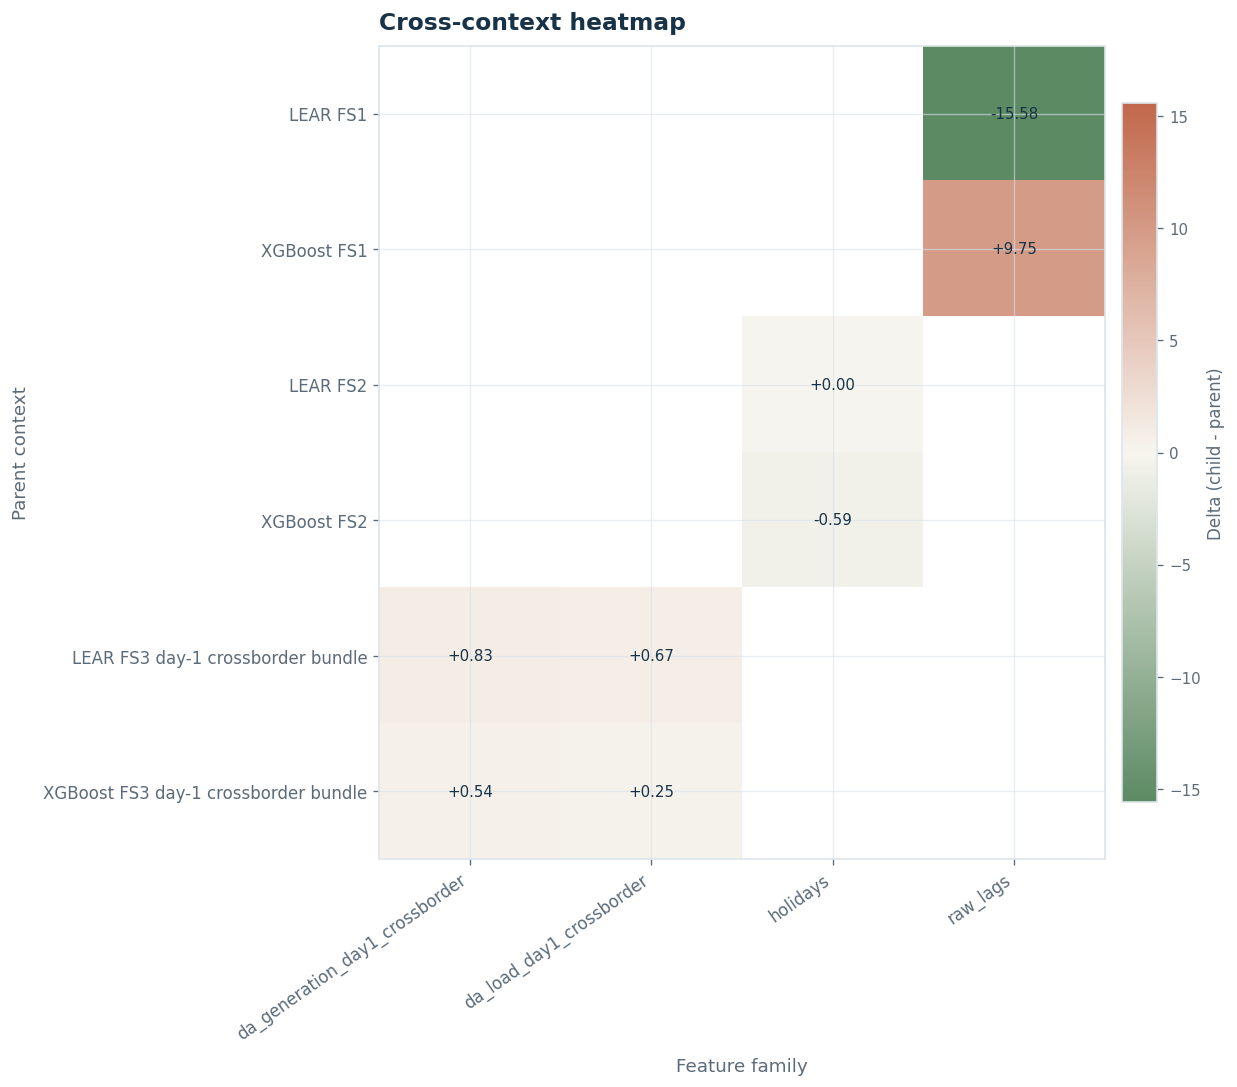

In [5]:
primary_summary = select_feature_family_metric_slice(
    summary_all,
    split=PRIMARY_SPLIT,
    reporting_level=PRIMARY_REPORTING_LEVEL,
    metric=PRIMARY_METRIC,
)

if primary_summary.empty:
    print("No complete ablation artifacts are available yet for the primary synthesis lens.")
else:
    overview_table = primary_summary[
        [
            "parent_context",
            "feature_family",
            "parent_value",
            "child_value",
            "delta",
            "relative_delta",
            "interpretation_flag",
            "smoke_test",
        ]
    ].rename(
        columns={
            "parent_context": "Parent context",
            "feature_family": "Feature family",
            "parent_value": "Parent value",
            "child_value": "Child value",
            "delta": "Delta",
            "relative_delta": "Relative delta",
            "interpretation_flag": "Interpretation",
            "smoke_test": "Smoke test",
        }
    )
    display(
        overview_table.style
        .format(
            {
                "Parent value": "{:.2f}",
                "Child value": "{:.2f}",
                "Delta": "{:+.2f}",
                "Relative delta": "{:+.2%}",
                "Smoke test": lambda value: "Yes" if bool(value) else "",
            }
        )
        .hide(axis="index")
    )

    fig = plot_feature_family_delta_bars(primary_summary)
    if fig is not None:
        display(fig)
        plt.close(fig)

    heatmap_fig = plot_feature_family_heatmap(primary_summary)
    if heatmap_fig is not None:
        display(heatmap_fig)
        plt.close(heatmap_fig)


## Results By Parent Context


### LEAR FS1

Saved context status: **smoke test**. Treat the tables below as interface-level evidence and not as a stable ranking yet.

,Parent context,Parent model,FS stage,Parent run,Aggregate run,Settings inheritance,Frozen naive reference,Saved feature families
0,LEAR FS1,lear_fs1,FS1,20260409_093141_lear_fs1_benchmark,20260420_091126_feature_family_ablation__lear_fs1_benchmark,reuse_parent_stage_tuned_hyperparameters,lear_fs1_benchmark,raw_lags


Key read: the largest harmful removal under the primary lens is `raw_lags` (`delta = -15.58`). The weakest entry under the same lens is `raw_lags` (`delta = -15.58`).

Feature family,Parent value,Child value,Delta,Relative delta,Interpretation
raw_lags,54.72,39.15,-15.58,-28.47%,improved when removed


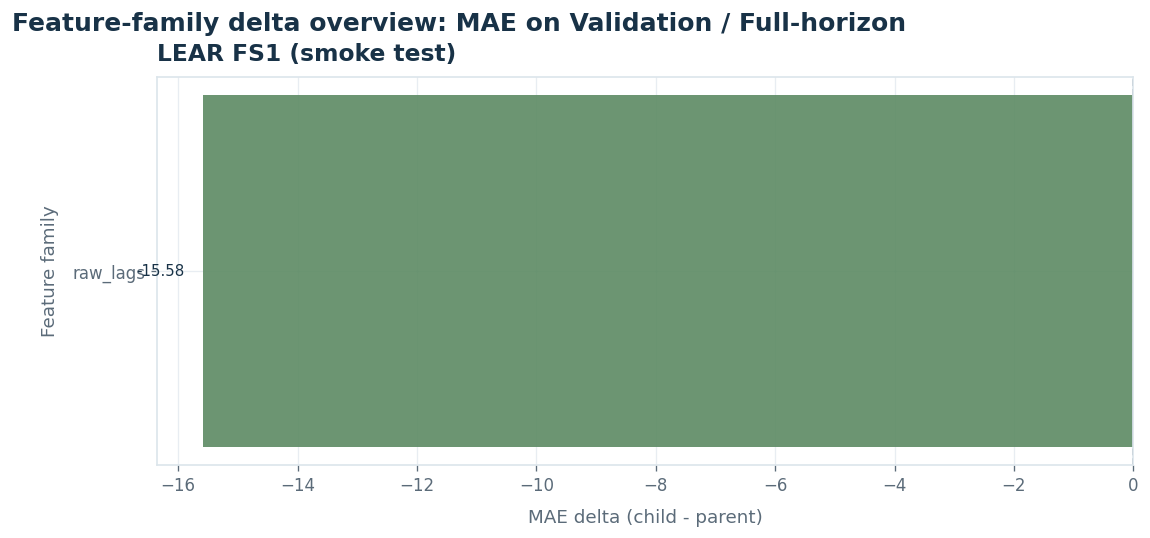

Split,Reporting level,Feature family,Metric,Delta,Relative delta
test,Overall,raw_lags,mae,-1.12,-4.48%
test,Overall,raw_lags,rmae_vs_official_naive,-0.03,-4.48%
test,D only,raw_lags,mae,+8.74,+32.06%
test,D only,raw_lags,rmae_vs_official_naive,+0.26,+32.06%
test,Guidance only,raw_lags,mae,-3.61,-14.77%
test,Guidance only,raw_lags,rmae_vs_official_naive,-0.11,-14.77%
test,Full-horizon,raw_lags,mae,-1.12,-4.48%
test,Full-horizon,raw_lags,rmae_vs_official_naive,-0.03,-4.48%
validation,Overall,raw_lags,mae,-15.58,-28.47%
validation,Overall,raw_lags,rmae_vs_official_naive,-0.56,-28.47%


### XGBoost FS1

Saved context status: **smoke test**. Treat the tables below as interface-level evidence and not as a stable ranking yet.

,Parent context,Parent model,FS stage,Parent run,Aggregate run,Settings inheritance,Frozen naive reference,Saved feature families
0,XGBoost FS1,xgboost_fs1,FS1,20260409_093911_xgboost_fs1_benchmark,20260420_091142_feature_family_ablation__xgboost_fs1_benchmark,reuse_parent_stage_tuned_hyperparameters,xgboost_fs1_benchmark,raw_lags


Key read: the largest harmful removal under the primary lens is `raw_lags` (`delta = +9.75`). The weakest entry under the same lens is `raw_lags` (`delta = +9.75`).

Feature family,Parent value,Child value,Delta,Relative delta,Interpretation
raw_lags,27.41,37.17,+9.75,+35.58%,strong loss when removed


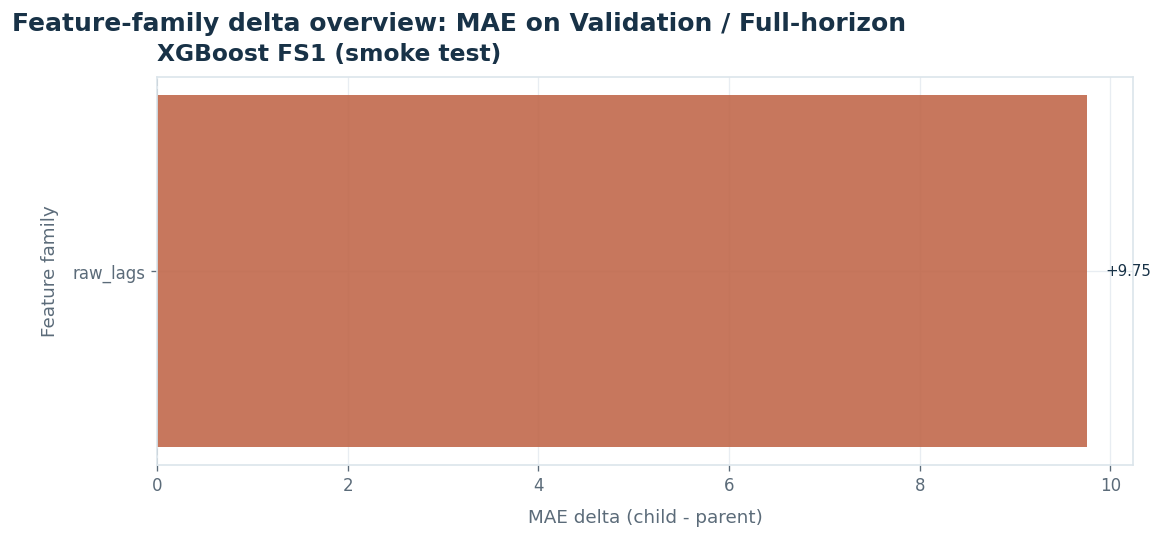

Split,Reporting level,Feature family,Metric,Delta,Relative delta
test,Overall,raw_lags,mae,+6.61,+15.46%
test,Overall,raw_lags,rmae_vs_official_naive,+0.20,+15.46%
test,D only,raw_lags,mae,+12.57,+38.04%
test,D only,raw_lags,rmae_vs_official_naive,+0.38,+38.04%
test,Guidance only,raw_lags,mae,+5.11,+11.29%
test,Guidance only,raw_lags,rmae_vs_official_naive,+0.15,+11.29%
test,Full-horizon,raw_lags,mae,+6.61,+15.46%
test,Full-horizon,raw_lags,rmae_vs_official_naive,+0.20,+15.46%
validation,Overall,raw_lags,mae,+9.75,+35.58%
validation,Overall,raw_lags,rmae_vs_official_naive,+0.35,+35.58%


### LEAR FS2

Saved context status: **smoke test**. Treat the tables below as interface-level evidence and not as a stable ranking yet.

,Parent context,Parent model,FS stage,Parent run,Aggregate run,Settings inheritance,Frozen naive reference,Saved feature families
0,LEAR FS2,lear_fs2,FS2,20260409_102003_lear_fs2_benchmark,20260420_091206_feature_family_ablation__lear_fs2_benchmark,reuse_parent_stage_tuned_hyperparameters,lear_fs2_benchmark,holidays


Key read: the largest harmful removal under the primary lens is `holidays` (`delta = +0.00`). The weakest entry under the same lens is `holidays` (`delta = +0.00`).

...

### XGBoost FS2

Saved context status: **smoke test**. Treat the tables below as interface-level evidence and not as a stable ranking yet.

,Parent context,Parent model,FS stage,Parent run,Aggregate run,Settings inheritance,Frozen naive reference,Saved feature families
0,XGBoost FS2,xgboost_fs2,FS2,20260409_103625_xgboost_fs2_benchmark,20260420_091227_feature_family_ablation__xgboost_fs2_benchmark,reuse_parent_stage_tuned_hyperparameters,xgboost_fs2_benchmark,holidays


Key read: the largest harmful removal under the primary lens is `holidays` (`delta = -0.59`). The weakest entry under the same lens is `holidays` (`delta = -0.59`).

Feature family,Parent value,Child value,Delta,Relative delta,Interpretation
holidays,24.16,23.57,-0.59,-2.45%,small mixed effect


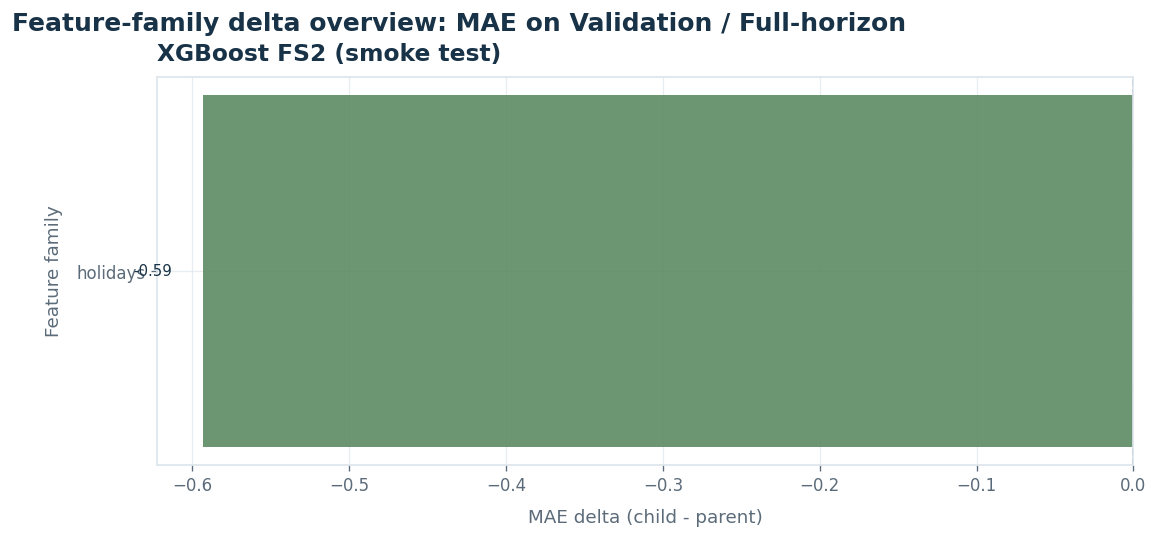

Split,Reporting level,Feature family,Metric,Delta,Relative delta
test,Overall,holidays,mae,-7.60,-26.93%
test,Overall,holidays,rmae_vs_official_naive,-0.23,-26.93%
test,D only,holidays,mae,-3.98,-12.11%
test,D only,holidays,rmae_vs_official_naive,-0.12,-12.11%
test,Guidance only,holidays,mae,-8.52,-31.47%
test,Guidance only,holidays,rmae_vs_official_naive,-0.26,-31.47%
test,Full-horizon,holidays,mae,-7.60,-26.93%
test,Full-horizon,holidays,rmae_vs_official_naive,-0.23,-26.93%
validation,Overall,holidays,mae,-0.59,-2.45%
validation,Overall,holidays,rmae_vs_official_naive,-0.02,-2.45%


### LEAR FS3 day-1 crossborder bundle

Saved context status: **smoke test**. Treat the tables below as interface-level evidence and not as a stable ranking yet.

,Parent context,Parent model,FS stage,Parent run,Aggregate run,Settings inheritance,Frozen naive reference,Saved feature families
0,LEAR FS3 day-1 crossborder bundle,lear_fs3_day1_crossborder_bundle,FS3,20260420_110602_fs3_day1_only_lear_day1_crossborder_bundle_parent,20260420_110621_feature_family_ablation__fs3_day1_only_lear_day1_crossborder_bundle_parent,reuse_parent_stage_tuned_hyperparameters,fs3_day1_only_lear_day1_crossborder_bundle_parent,"da_load_day1_crossborder, da_generation_day1_crossborder"


Key read: the largest harmful removal under the primary lens is `da_generation_day1_crossborder` (`delta = +0.83`). The weakest entry under the same lens is `da_load_day1_crossborder` (`delta = +0.67`).

Feature family,Parent value,Child value,Delta,Relative delta,Interpretation
da_generation_day1_crossborder,44.63,45.46,+0.83,+1.85%,modest loss when removed
da_load_day1_crossborder,44.63,45.30,+0.67,+1.49%,modest loss when removed


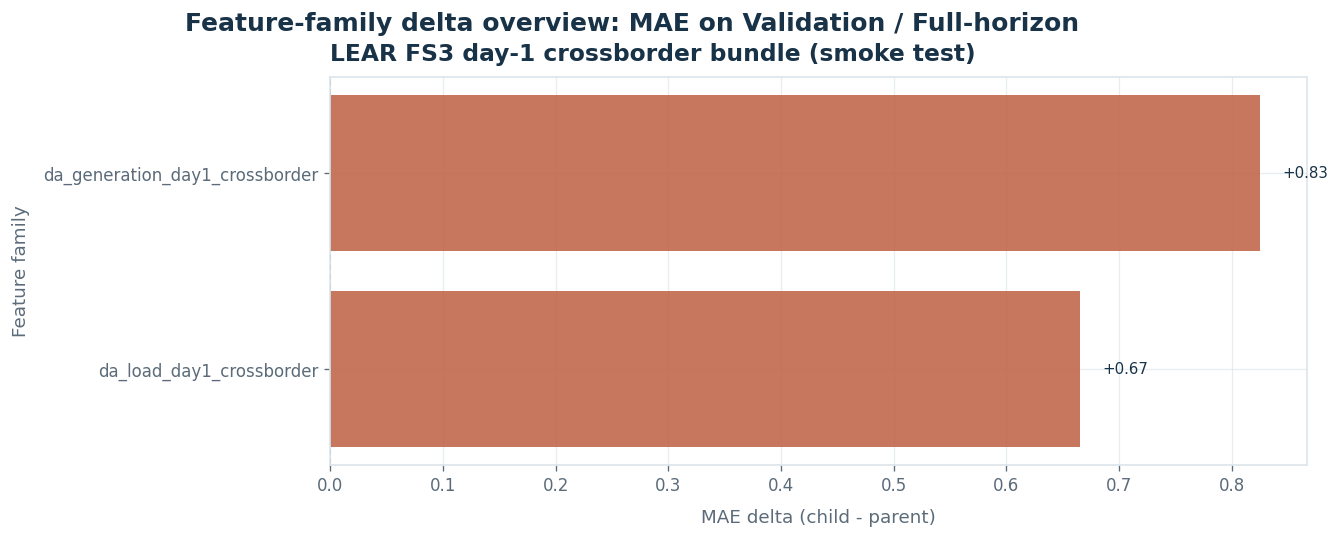

Split,Reporting level,Feature family,Metric,Delta,Relative delta
test,Overall,da_load_day1_crossborder,mae,+2.23,+22.41%
test,Overall,da_load_day1_crossborder,rmae_vs_official_naive,+0.05,+22.41%
test,D only,da_load_day1_crossborder,mae,+11.04,+92.27%
test,D only,da_load_day1_crossborder,rmae_vs_official_naive,+0.38,+92.27%
test,Guidance only,da_load_day1_crossborder,mae,+0.00,+0.00%
test,Guidance only,da_load_day1_crossborder,rmae_vs_official_naive,+0.00,+0.00%
test,Full-horizon,da_load_day1_crossborder,mae,+2.23,+22.41%
test,Full-horizon,da_load_day1_crossborder,rmae_vs_official_naive,+0.05,+22.41%
validation,Overall,da_load_day1_crossborder,mae,+0.67,+1.49%
validation,Overall,da_load_day1_crossborder,rmae_vs_official_naive,+0.02,+1.49%


### XGBoost FS3 day-1 crossborder bundle

Saved context status: **smoke test**. Treat the tables below as interface-level evidence and not as a stable ranking yet.

,Parent context,Parent model,FS stage,Parent run,Aggregate run,Settings inheritance,Frozen naive reference,Saved feature families
0,XGBoost FS3 day-1 crossborder bundle,xgboost_fs3_day1_crossborder_bundle,FS3,20260420_105851_fs3_day1_only_xgboost_day1_crossborder_bundle_parent,20260420_105856_feature_family_ablation__fs3_day1_only_xgboost_day1_crossborder_bundle_parent,reuse_parent_stage_tuned_hyperparameters,fs3_day1_only_xgboost_day1_crossborder_bundle_parent,"da_load_day1_crossborder, da_generation_day1_crossborder"


Key read: the largest harmful removal under the primary lens is `da_generation_day1_crossborder` (`delta = +0.54`). The weakest entry under the same lens is `da_load_day1_crossborder` (`delta = +0.25`).

Feature family,Parent value,Child value,Delta,Relative delta,Interpretation
da_generation_day1_crossborder,23.76,24.30,+0.54,+2.27%,modest loss when removed
da_load_day1_crossborder,23.76,24.01,+0.25,+1.07%,modest loss when removed


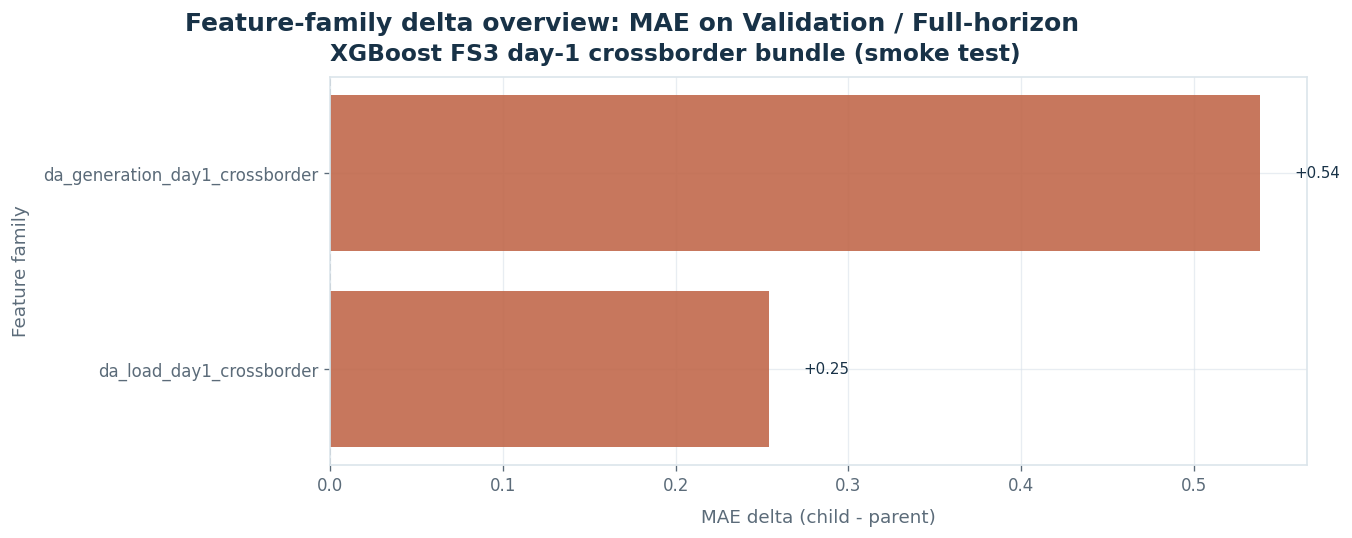

Split,Reporting level,Feature family,Metric,Delta,Relative delta
test,Overall,da_load_day1_crossborder,mae,+0.05,+0.18%
test,Overall,da_load_day1_crossborder,rmae_vs_official_naive,+0.00,+0.18%
test,D only,da_load_day1_crossborder,mae,+0.25,+0.86%
test,D only,da_load_day1_crossborder,rmae_vs_official_naive,+0.01,+0.86%
test,Guidance only,da_load_day1_crossborder,mae,+0.00,+0.00%
test,Guidance only,da_load_day1_crossborder,rmae_vs_official_naive,+0.00,+0.00%
test,Full-horizon,da_load_day1_crossborder,mae,+0.05,+0.18%
test,Full-horizon,da_load_day1_crossborder,rmae_vs_official_naive,+0.00,+0.18%
validation,Overall,da_load_day1_crossborder,mae,+0.25,+1.07%
validation,Overall,da_load_day1_crossborder,rmae_vs_official_naive,+0.01,+1.07%


In [6]:
if not bundles:
    print("No complete grouped-ablation bundles are available yet.")
else:
    for bundle in bundles:
        metadata = bundle["metadata"]
        context_label = bundle["context_label"]
        context_summary = select_feature_family_metric_slice(
            bundle["summary"],
            split=PRIMARY_SPLIT,
            reporting_level=PRIMARY_REPORTING_LEVEL,
            metric=PRIMARY_METRIC,
        )

        display(Markdown(f"### {context_label}"))
        if bool(metadata.get("smoke_test", False)):
            display(
                Markdown(
                    "Saved context status: **smoke test**. "
                    "Treat the tables below as interface-level evidence and not as a stable ranking yet."
                )
            )

        metadata_view = pd.DataFrame(
            [
                {
                    "Parent context": context_label,
                    "Parent model": metadata.get("model", ""),
                    "FS stage": metadata.get("fs_stage", ""),
                    "Parent run": metadata.get("parent_run_id", ""),
                    "Aggregate run": metadata.get("run_id", ""),
                    "Settings inheritance": metadata.get("settings_inheritance_policy", ""),
                    "Frozen naive reference": metadata.get("parent_benchmark_rmae_reference", {}).get(
                        "rmae_denominator_source_run_label", ""
                    ),
                    "Saved feature families": ", ".join(metadata.get("selected_feature_families", [])) or "-",
                }
            ]
        )
        display(metadata_view)

        if context_summary.empty:
            print("No primary-lens rows are available for this context.")
        else:
            top_row = context_summary.iloc[0]
            bottom_row = context_summary.iloc[-1]
            display(
                Markdown(
                    f"Key read: the largest harmful removal under the primary lens is "
                    f"`{top_row['feature_family']}` (`delta = {float(top_row['delta']):+.2f}`). "
                    f"The weakest entry under the same lens is "
                    f"`{bottom_row['feature_family']}` (`delta = {float(bottom_row['delta']):+.2f}`)."
                )
            )
            context_table = context_summary[
                [
                    "feature_family",
                    "parent_value",
                    "child_value",
                    "delta",
                    "relative_delta",
                    "interpretation_flag",
                ]
            ].rename(
                columns={
                    "feature_family": "Feature family",
                    "parent_value": "Parent value",
                    "child_value": "Child value",
                    "delta": "Delta",
                    "relative_delta": "Relative delta",
                    "interpretation_flag": "Interpretation",
                }
            )
            display(
                context_table.style
                .format(
                    {
                        "Parent value": "{:.2f}",
                        "Child value": "{:.2f}",
                        "Delta": "{:+.2f}",
                        "Relative delta": "{:+.2%}",
                    }
                )
                .hide(axis="index")
            )

            context_fig = plot_feature_family_delta_bars(context_summary)
            if context_fig is not None:
                display(context_fig)
                plt.close(context_fig)

        reporting_view = bundle["by_reporting_level"].copy()
        reporting_view = reporting_view[reporting_view["metric"].isin(["mae", "rmae_vs_official_naive"])].copy()
        reporting_view = reporting_view[
            [
                "dataset_split",
                "reporting_level_label",
                "feature_family",
                "metric",
                "delta",
                "relative_delta",
            ]
        ].rename(
            columns={
                "dataset_split": "Split",
                "reporting_level_label": "Reporting level",
                "feature_family": "Feature family",
                "metric": "Metric",
                "delta": "Delta",
                "relative_delta": "Relative delta",
            }
        )
        if not reporting_view.empty:
            display(
                reporting_view.style
                .format({"Delta": "{:+.2f}", "Relative delta": "{:+.2%}"})
                .hide(axis="index")
            )


## Cross-Context Synthesis


In [7]:
cross_context = summarize_feature_family_cross_context(
    summary_all,
    split=PRIMARY_SPLIT,
    reporting_level=PRIMARY_REPORTING_LEVEL,
    metric=PRIMARY_METRIC,
)

if cross_context.empty:
    print("No cross-context summary can be built yet.")
else:
    synthesis_view = cross_context.rename(
        columns={
            "feature_family": "Feature family",
            "contexts_available": "Contexts available",
            "context_count": "Context count",
            "mean_delta": "Mean delta",
            "mean_relative_delta": "Mean relative delta",
            "removal_hurt_count": "Removal hurt count",
            "removal_help_count": "Removal help count",
            "smoke_test_context_count": "Smoke-test contexts",
            "stability_note": "Stability note",
        }
    )
    display(
        synthesis_view.style
        .format({"Mean delta": "{:+.2f}", "Mean relative delta": "{:+.2%}"})
        .hide(axis="index")
    )

    stability_fig = plot_feature_family_origin_stability(
        by_origin_all,
        split=PRIMARY_SPLIT,
        reporting_level=PRIMARY_REPORTING_LEVEL,
        metric=PRIMARY_METRIC,
    )
    if stability_fig is None:
        print(
            "No readable origin-stability plot is available yet. "
            "Current saved contexts are either smoke tests or have too few origins for a meaningful spread view."
        )
    else:
        display(stability_fig)
        plt.close(stability_fig)


Feature family,Contexts available,Context count,Mean delta,Mean relative delta,Removal hurt count,Removal help count,Smoke-test contexts,Stability note
da_generation_day1_crossborder,"LEAR FS3 day-1 crossborder bundle, XGBoost FS3 day-1 crossborder bundle",2,+0.68,+2.06%,2,0,2,Consistently valuable where tested (smoke-test evidence only)
da_load_day1_crossborder,"LEAR FS3 day-1 crossborder bundle, XGBoost FS3 day-1 crossborder bundle",2,+0.46,+1.28%,2,0,2,Consistently valuable where tested (smoke-test evidence only)
holidays,"LEAR FS2, XGBoost FS2",2,-0.30,-1.23%,1,1,2,Model/stage specific pattern (smoke-test evidence only)
raw_lags,"LEAR FS1, XGBoost FS1",2,-2.91,+3.56%,1,1,2,Model/stage specific pattern (smoke-test evidence only)


No readable origin-stability plot is available yet. Current saved contexts are either smoke tests or have too few origins for a meaningful spread view.


## Practical Interpretation And Limits

How to read the current results:
- preserve feature families that repeatedly cause a clear loss when removed inside the same parent context
- treat families with near-zero or negative delta as candidates for later scrutiny, not automatic deletion
- compare contexts carefully: `FS1` and `FS2` are related but not identical design stages
- use these ablation findings to inform later `FS3` planning, not to overclaim a universal ranking

Current limitations:
- this is rolling-origin evidence, not fold CV
- `Prophet` coverage may be absent or incomplete if the package is unavailable
- grouped ablation is the main evidence here; heavier model-native interpretation can stay optional later
- saved smoke-test runs are useful for interface validation but are not strong enough for stability claims
